# Winter Wheat PVTT: Temperature Response & Model Dynamics

Loads the PEP725 winter wheat phenology observations (no weather download),
uses the **pre-calibrated** PVTT model (no fitting step), and explores model
dynamics with **synthetic** seasonal temperature series.

**Sections**
1. Load PEP725 observations (no feature download)
2. Pre-calibrated PVTT model
3. Synthetic temperature model
4. Temperature response functions
5. Season dynamics
6. Winter temperature sensitivity sweep
7. Internal dynamics across winter temperature scenarios

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pysephone.constants import KEY_FEATURES, KEY_OBSERVATIONS_INDEX
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.models.pvtt import CalibratedPVTTModel
from pysephone.models.util.func_phenology import (
    func_vernalization_unit,
    func_vernalization_tres,
    func_photoperiod_factor,
    func_growing_degree_units_2,
)
from pysephone.utils.func import create_left_mask

OBS_KEY = 'BBCH_51'  # ear emergence / heading
SOW_KEY = 'BBCH_0'  # sowing

# ── colour palette ────────────────────────────────────────────────────────
C_PVTT  = '#2980b9'
C_WARM  = '#f4a46240'
C_COLD  = '#7eb8d440'
C_TLINE = '#c0392b'
C_ZERO  = '#cccccc'

# ── season-axis helpers ───────────────────────────────────────────────────
_MONTH_STARTS = [0, 31, 61, 92, 122, 153, 181, 212, 243, 273, 304, 334]
_MONTH_LABELS = ['Oct','Nov','Dec','Jan','Feb','Mar',
                  'Apr','May','Jun','Jul','Aug','Sep']

def _month_ticks(n):
    t = [d for d in _MONTH_STARTS if d < n]
    l = [_MONTH_LABELS[i] for i, d in enumerate(_MONTH_STARTS) if d < n]
    return t, l

def _style_ax(ax, n, ylabel='', xlabel=False):
    ax.set_xlim(0, n - 1)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    t, l = _month_ticks(n)
    ax.set_xticks(t)
    ax.set_xticklabels(l if xlabel else [], fontsize=8)
    if xlabel:
        ax.set_xlabel('Month (season from Oct 1)', fontsize=9)

## 1. Load PEP725 winter wheat observations

Load observation metadata only — no weather feature download.
This gives us the distribution of sowing and heading dates across
stations and years, which we use to ground the synthetic temperature analysis.

In [2]:
cal = Calendar(default_start='09-01', default_length=365)
ds  = Dataset.load('CPF_PEP725_winter_wheat', calendar=cal, feature_providers=[])

rows = []
for sample in ds.iter_items():
    obs_ix = sample.get('observations_index', {})
    if OBS_KEY not in obs_ix:
        continue
    rows.append({
        'year':       sample['year'],
        'loc_id':     sample['loc_id'],
        'country':    sample.get('country_code', '?'),
        'heading_ix': int(obs_ix[OBS_KEY]),
        'sow_ix':     int(obs_ix[SOW_KEY]) if SOW_KEY in obs_ix else np.nan,
    })

df_obs = pd.DataFrame(rows)
print(f'{len(df_obs)} samples across {df_obs["loc_id"].nunique()} stations,'
      f' {df_obs["year"].nunique()} years ({df_obs["year"].min()}–{df_obs["year"].max()})')
print(f'Countries: {", ".join(sorted(df_obs["country"].unique()))}')
print()
print(df_obs[['heading_ix', 'sow_ix']].describe().round(1))

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 3299.15it/s]


5284 samples across 683 stations, 28 years (1987–2015)
Countries: ?

       heading_ix  sow_ix
count      5284.0  5284.0
mean        273.6    35.9
std           8.1     9.5
min         248.0     4.0
25%         268.0    31.0
50%         273.0    37.0
75%         279.0    42.0
max         301.0    67.0


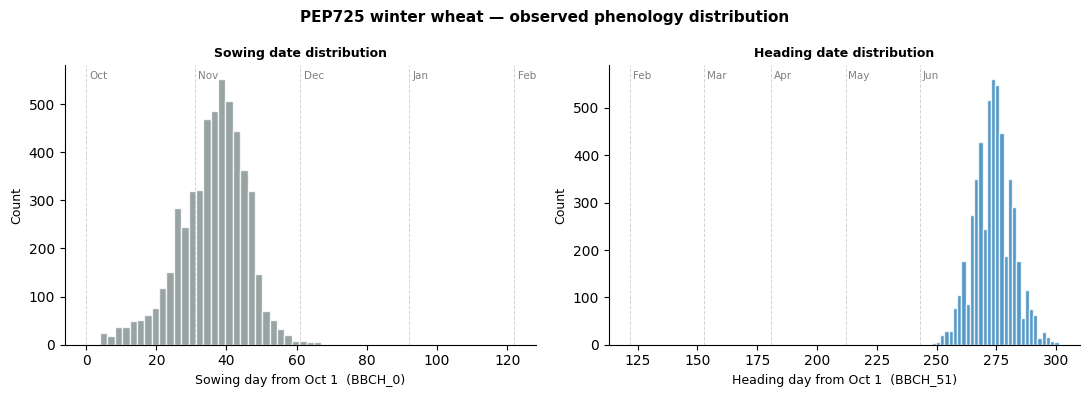

Typical sowing day: 37  (Nov)
Typical heading day: 273 (Jul)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('PEP725 winter wheat — observed phenology distribution', fontsize=11, fontweight='bold')

ax = axes[0]
ax.hist(df_obs['sow_ix'].dropna(), bins=30, color='#7f8c8d', alpha=0.8, edgecolor='white')
ax.set_xlabel('Sowing day from Oct 1  (BBCH_0)', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.set_title('Sowing date distribution', fontsize=9, fontweight='bold')
# Annotate with month labels
for d, m in zip(_MONTH_STARTS[:5], _MONTH_LABELS[:5]):
    ax.axvline(d, color='lightgrey', lw=0.7, ls='--')
    ax.text(d + 1, ax.get_ylim()[1] * 0.95, m, fontsize=7.5, color='grey')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
ax.hist(df_obs['heading_ix'], bins=30, color=C_PVTT, alpha=0.8, edgecolor='white')
ax.set_xlabel('Heading day from Oct 1  (BBCH_51)', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.set_title('Heading date distribution', fontsize=9, fontweight='bold')
for d, m in zip(_MONTH_STARTS[4:9], _MONTH_LABELS[4:9]):
    ax.axvline(d, color='lightgrey', lw=0.7, ls='--')
    ax.text(d + 1, ax.get_ylim()[1] * 0.95, m, fontsize=7.5, color='grey')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

TYPICAL_SOW_IX = int(df_obs['sow_ix'].dropna().median())
TYPICAL_HEAD_IX = int(df_obs['heading_ix'].median())
print(f'Typical sowing day: {TYPICAL_SOW_IX}  ({_MONTH_LABELS[next(i for i,d in enumerate(_MONTH_STARTS) if d > TYPICAL_SOW_IX) - 1]})')
print(f'Typical heading day: {TYPICAL_HEAD_IX} ({_MONTH_LABELS[next(i for i,d in enumerate(_MONTH_STARTS) if d > TYPICAL_HEAD_IX) - 1]})')

## 2. Pre-calibrated PVTT model

`CalibratedPVTTModel` uses literature-based parameters from
*"Climate change effects on wheat phenology depends on cultivar change"*.
No fitting required.

In [4]:
pvtt = CalibratedPVTTModel()

param_rows = [
    ('threshold_pvtt', pvtt.threshold_pvtt, 'degree-days', 'Cumulative PVTT required for heading'),
    ('threshold_vern', pvtt.threshold_vern, 'vern. units', 'Units accumulated for full vernalization'),
    ('t_base',         pvtt.t_base,         '°C',          'Base temperature for thermal time'),
    ('t_limit',        pvtt.t_limit,        '°C',          'Optimal temperature (GDU₂ peak)'),
    ('t_upper',        pvtt.t_upper,        '°C',          'Upper temperature limit (GDU₂ = 0 above)'),
    ('p_base',         pvtt.p_base,         'hours',       'Min daylight for any photoperiod response'),
    ('p_saturation',   pvtt.p_saturation,   'hours',       'Daylight for full photoperiod response'),
]
display(pd.DataFrame(param_rows, columns=['Parameter', 'Value', 'Units', 'Meaning']))

,Parameter,Value,Units,Meaning
0,threshold_pvtt,800.0,degree-days,Cumulative PVTT required for heading
1,threshold_vern,30.0,vern. units,Units accumulated for full vernalization
2,t_base,1.0,°C,Base temperature for thermal time
3,t_limit,32.0,°C,Optimal temperature (GDU₂ peak)
4,t_upper,40.0,°C,Upper temperature limit (GDU₂ = 0 above)
5,p_base,7.0,hours,Min daylight for any photoperiod response
6,p_saturation,17.0,hours,Daylight for full photoperiod response


## 3. Synthetic temperature model

Seasons are generated as piecewise-constant profiles with added Gaussian noise:

| Period | Days (from Oct 1) | Temperature |
|---|---|---|
| Pre-sowing | 0 → sow_ix | +10 °C (warm autumn) |
| Winter | sow_ix → 150 | **varied** (the control parameter) |
| Spring | 150 → 250 | +12 °C |
| Summer | 250 → 365 | +18 °C |

Daylight duration follows a smooth seasonal sinusoid anchored to Oct 1.

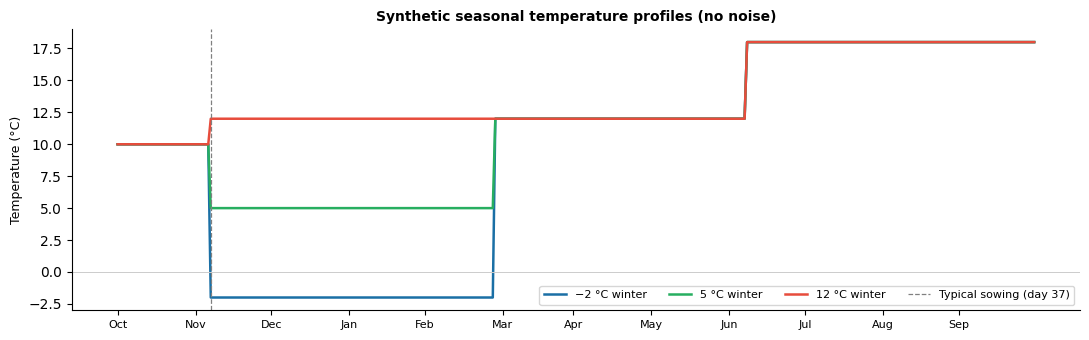

In [5]:
def _daylight_series(n=365):
    """Synthetic seasonal daylight series (seconds), starting Oct 1."""
    days = np.arange(n)
    # Peak in Jun (~day 273 from Oct 1), trough in Dec (~day 92)
    return (12.0 - 4.0 * np.cos(2 * np.pi * (days - 81) / 365)) * 3600.0


def make_sample(
    mean_winter_temp: float,
    mean_spring_temp: float = 12.0,
    noise_std:        float = 1.5,
    sow_ix:           int   = None,
    seed:             int   = 0,
) -> dict:
    """Piecewise synthetic season: warm autumn → winter → spring → summer."""
    if sow_ix is None:
        sow_ix = TYPICAL_SOW_IX
    rng = np.random.default_rng(seed)
    ts  = np.zeros(365, dtype=np.float32)
    ts[0:sow_ix]   = 10.0
    ts[sow_ix:150] = mean_winter_temp
    ts[150:250]    = mean_spring_temp
    ts[250:]       = 18.0
    ts += rng.normal(0, noise_std, 365).astype(np.float32)
    return {
        KEY_FEATURES: {
            'temperature_2m_mean': ts,
            'daylight_duration':   _daylight_series(365).astype(np.float32),
        },
        KEY_OBSERVATIONS_INDEX: {SOW_KEY: sow_ix},
        'season_start': np.datetime64('1990-10-01'),
        'observations': {},
    }


# — show a few example profiles ——————————————————————————————————————————
fig, ax = plt.subplots(figsize=(11, 3.5))
for mw, color, label in [(-2, '#1a6fa5', '−2 °C winter'),
                           (5,  '#27ae60',  '5 °C winter'),
                           (12, '#e74c3c', '12 °C winter')]:
    sample = make_sample(mean_winter_temp=mw, noise_std=0)
    ts = sample[KEY_FEATURES]['temperature_2m_mean']
    ax.plot(np.arange(365), ts, color=color, lw=1.8, label=label)

ax.axvline(TYPICAL_SOW_IX, color='grey', ls='--', lw=0.9, label=f'Typical sowing (day {TYPICAL_SOW_IX})')
ax.axhline(0, color=C_ZERO, lw=0.7)
t, l = _month_ticks(365)
ax.set_xticks(t)
ax.set_xticklabels(l, fontsize=8)
ax.set_ylabel('Temperature (°C)', fontsize=9)
ax.set_title('Synthetic seasonal temperature profiles (no noise)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8, ncol=4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Temperature response functions

The three mathematical curves that govern PVTT's sensitivity to temperature
and photoperiod, plotted at the pre-calibrated parameter values.

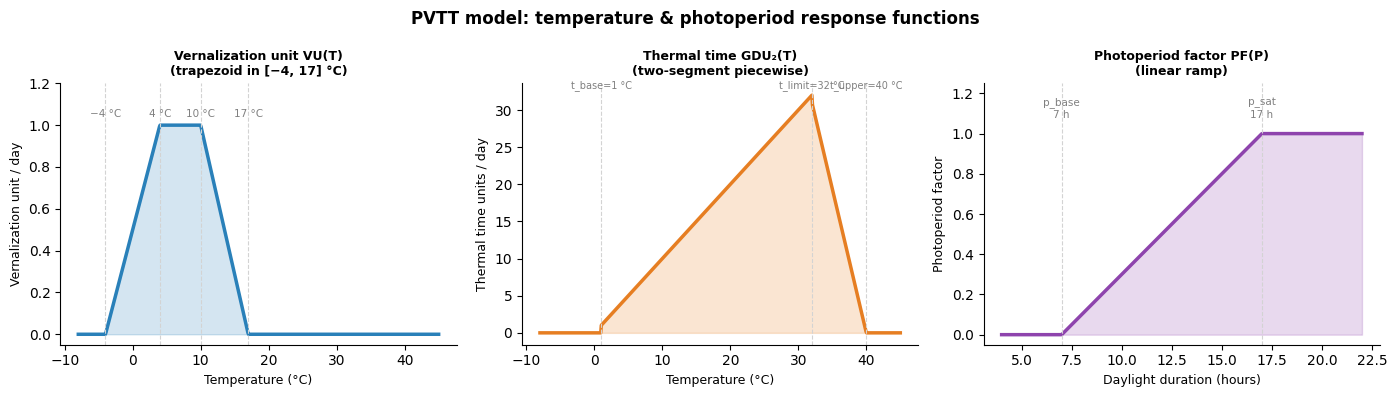

In [6]:
T_range = np.linspace(-8, 45, 600)
P_range = np.linspace(4, 22, 400)

vu_curve  = func_vernalization_unit(T_range)
gdu_curve = func_growing_degree_units_2(T_range,
                t_base=pvtt.t_base, t_limit=pvtt.t_limit, t_upper=pvtt.t_upper)
pf_curve  = func_photoperiod_factor(P_range, p_base=pvtt.p_base, p_sat=pvtt.p_saturation)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('PVTT model: temperature & photoperiod response functions', fontsize=12, fontweight='bold')

# — vernalization unit (trapezoid) ————————————————————————————————————
ax = axes[0]
ax.fill_between(T_range, vu_curve, alpha=0.2, color=C_PVTT)
ax.plot(T_range, vu_curve, color=C_PVTT, lw=2.5)
for t, lab in [(-4, '−4'), (4, '4'), (10, '10'), (17, '17')]:
    ax.axvline(t, color='lightgrey', lw=0.8, ls='--')
    ax.text(t, 1.04, f'{lab} °C', ha='center', fontsize=7.5, color='grey')
ax.set_xlabel('Temperature (°C)', fontsize=9)
ax.set_ylabel('Vernalization unit / day', fontsize=9)
ax.set_title('Vernalization unit VU(T)\n(trapezoid in [−4, 17] °C)', fontsize=9, fontweight='bold')
ax.set_ylim(-0.05, 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# — thermal time GDU₂ (two-segment) ——————————————————————————————————
ax = axes[1]
ax.fill_between(T_range, gdu_curve, alpha=0.2, color='#e67e22')
ax.plot(T_range, gdu_curve, color='#e67e22', lw=2.5)
for t, lab in [(pvtt.t_base,  f't_base={pvtt.t_base:.0f} °C'),
               (pvtt.t_limit, f't_limit={pvtt.t_limit:.0f} °C'),
               (pvtt.t_upper, f't_upper={pvtt.t_upper:.0f} °C')]:
    ax.axvline(t, color='lightgrey', lw=0.8, ls='--')
    ax.text(t, gdu_curve.max() * 1.03, lab, ha='center', fontsize=7, color='grey', rotation=0)
ax.set_xlabel('Temperature (°C)', fontsize=9)
ax.set_ylabel('Thermal time units / day', fontsize=9)
ax.set_title('Thermal time GDU₂(T)\n(two-segment piecewise)', fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# — photoperiod factor (linear ramp) ——————————————————————————————————
ax = axes[2]
ax.fill_between(P_range, pf_curve, alpha=0.2, color='#8e44ad')
ax.plot(P_range, pf_curve, color='#8e44ad', lw=2.5)
ax.axvline(pvtt.p_base,       color='lightgrey', lw=0.8, ls='--')
ax.axvline(pvtt.p_saturation, color='lightgrey', lw=0.8, ls='--')
ax.text(pvtt.p_base,       1.08, f'p_base\n{pvtt.p_base:.0f} h',   ha='center', fontsize=7.5, color='grey')
ax.text(pvtt.p_saturation, 1.08, f'p_sat\n{pvtt.p_saturation:.0f} h', ha='center', fontsize=7.5, color='grey')
ax.set_xlabel('Daylight duration (hours)', fontsize=9)
ax.set_ylabel('Photoperiod factor', fontsize=9)
ax.set_title('Photoperiod factor PF(P)\n(linear ramp)', fontsize=9, fontweight='bold')
ax.set_ylim(-0.05, 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

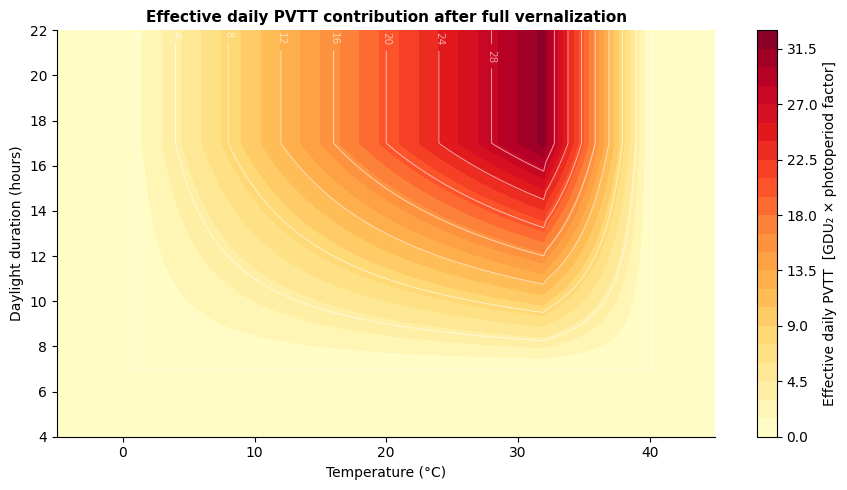

In [7]:
# — effective daily PVTT after full vernalization (GDU₂ × PF surface) ——
T_grid = np.linspace(-5, 45, 300)
P_grid = np.linspace(4, 22, 300)
T_mat, P_mat = np.meshgrid(T_grid, P_grid)

GDU_mat  = func_growing_degree_units_2(T_mat,
               t_base=pvtt.t_base, t_limit=pvtt.t_limit, t_upper=pvtt.t_upper)
PF_mat   = func_photoperiod_factor(P_mat, p_base=pvtt.p_base, p_sat=pvtt.p_saturation)
PVTT_mat = GDU_mat * PF_mat

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.contourf(T_grid, P_grid, PVTT_mat, levels=25, cmap='YlOrRd')
cs = ax.contour(T_grid, P_grid, PVTT_mat, levels=8, colors='white', linewidths=0.7, alpha=0.6)
ax.clabel(cs, fmt='%.0f', fontsize=7.5, colors='white')
plt.colorbar(im, ax=ax, label='Effective daily PVTT  [GDU₂ × photoperiod factor]')
ax.set_xlabel('Temperature (°C)', fontsize=10)
ax.set_ylabel('Daylight duration (hours)', fontsize=10)
ax.set_title('Effective daily PVTT contribution after full vernalization',
             fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Season dynamics

Visualise all five PVTT stages through a representative synthetic season:
temperature, daily vernalization units, vernalization factor, photoperiod
factor, and cumulative PVTT vs the heading threshold.

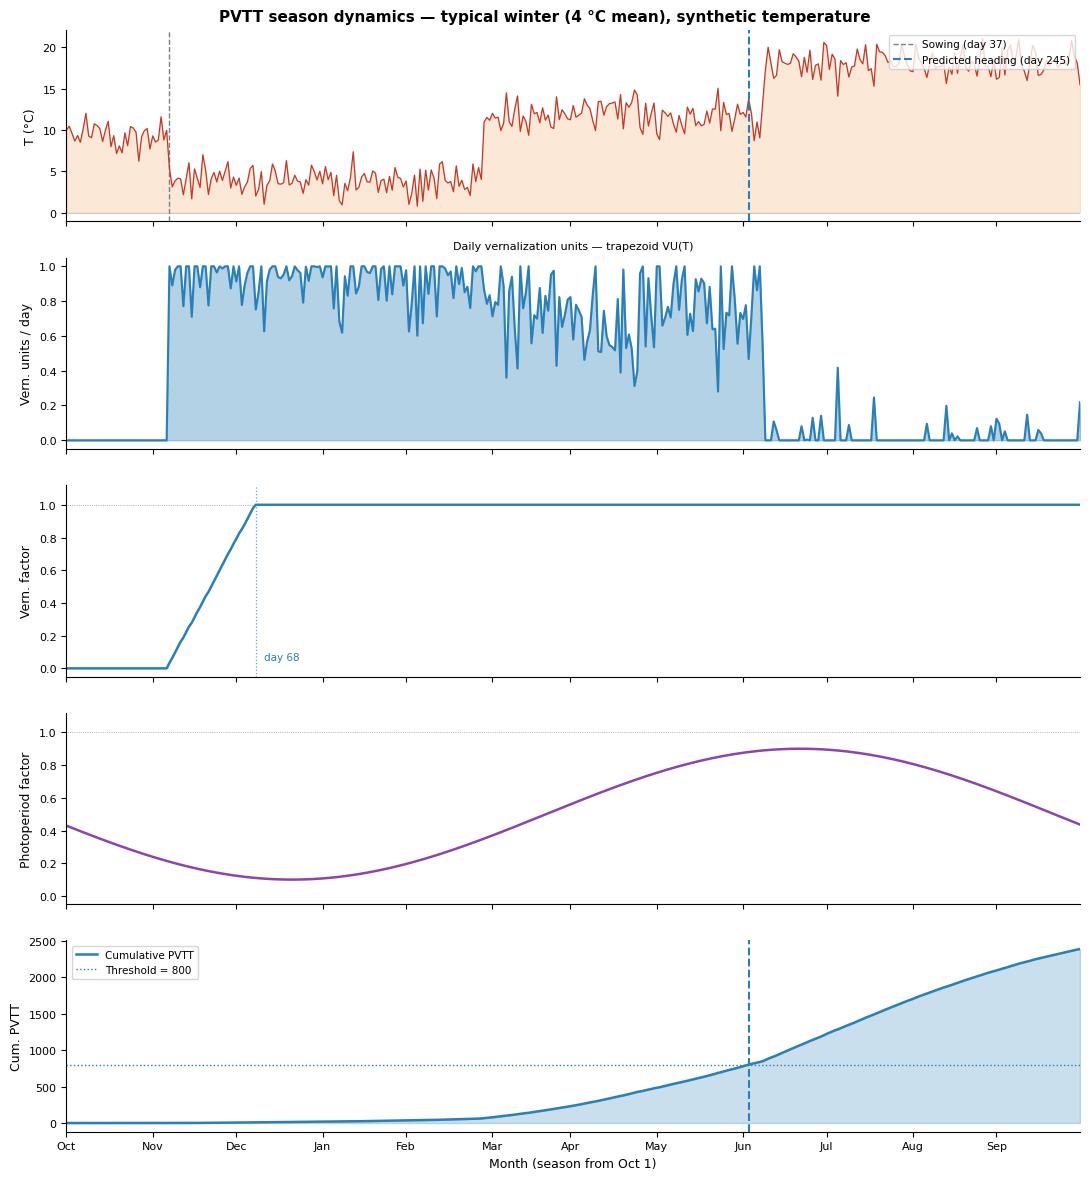

In [8]:
def plot_pvtt_dynamics(sample, title=''):
    ts  = sample[KEY_FEATURES]['temperature_2m_mean'].astype(float)
    ps  = sample[KEY_FEATURES]['daylight_duration'].astype(float) / 3600.0
    n   = len(ts)
    days    = np.arange(n)
    sow_ix  = int(sample[KEY_OBSERVATIONS_INDEX][SOW_KEY])
    mask    = create_left_mask(n, sow_ix)

    vu      = func_vernalization_unit(ts) * mask
    vt      = func_vernalization_tres(vu.cumsum(), threshold=pvtt.threshold_vern)
    pf      = func_photoperiod_factor(ps, p_base=pvtt.p_base, p_sat=pvtt.p_saturation)
    gdu     = func_growing_degree_units_2(ts, t_base=pvtt.t_base,
                                          t_limit=pvtt.t_limit, t_upper=pvtt.t_upper)
    pvtt_d  = gdu * mask * vt * pf
    pvtt_cs = pvtt_d.cumsum()

    _, info = pvtt.predict(sample)
    pred_ix = info['ix']
    req_met = info['req_met']

    fig, axes = plt.subplots(5, 1, figsize=(11, 12), sharex=True)
    if title:
        fig.suptitle(title, fontsize=11, fontweight='bold')

    # — temperature —
    ax = axes[0]
    ax.axhline(0, color=C_ZERO, lw=0.8)
    ax.axvline(sow_ix, color='grey', lw=1.0, ls='--', label=f'Sowing (day {sow_ix})')
    ax.fill_between(days, ts, 0, where=(ts >= 0), color=C_WARM)
    ax.fill_between(days, ts, 0, where=(ts <  0), color=C_COLD)
    ax.plot(days, ts, color=C_TLINE, lw=0.9)
    if req_met:
        ax.axvline(pred_ix, color=C_PVTT, lw=1.5, ls='--',
                   label=f'Predicted heading (day {pred_ix})')
    _style_ax(ax, n, ylabel='T (°C)')
    ax.legend(fontsize=7.5, loc='upper right')

    # — daily vernalization units —
    ax = axes[1]
    ax.fill_between(days, vu, color=C_PVTT, alpha=0.35)
    ax.plot(days, vu, color=C_PVTT, lw=1.5)
    _style_ax(ax, n, ylabel='Vern. units / day')
    ax.set_title('Daily vernalization units — trapezoid VU(T)', fontsize=8)

    # — vernalization factor —
    ax = axes[2]
    ax.plot(days, vt, color=C_PVTT, lw=1.8)
    ax.axhline(1.0, color='grey', lw=0.5, ls=':')
    done = np.where(vt >= 1.0)[0]
    if len(done):
        ax.axvline(done[0], color=C_PVTT, lw=0.9, ls=':', alpha=0.7)
        ax.text(done[0] + 3, 0.05, f'day {done[0]}', fontsize=7.5, color=C_PVTT)
    _style_ax(ax, n, ylabel='Vern. factor')
    ax.set_ylim(-0.05, 1.12)

    # — photoperiod factor —
    ax = axes[3]
    ax.plot(days, pf, color='#8e44ad', lw=1.8)
    ax.axhline(1.0, color='grey', lw=0.5, ls=':')
    _style_ax(ax, n, ylabel='Photoperiod factor')
    ax.set_ylim(-0.05, 1.12)

    # — cumulative PVTT —
    ax = axes[4]
    ax.fill_between(days, pvtt_cs, color=C_PVTT, alpha=0.25)
    ax.plot(days, pvtt_cs, color=C_PVTT, lw=1.8, label='Cumulative PVTT')
    ax.axhline(pvtt.threshold_pvtt, color=C_PVTT, lw=1.0, ls=':',
               label=f'Threshold = {pvtt.threshold_pvtt:.0f}')
    if req_met:
        ax.axvline(pred_ix, color=C_PVTT, lw=1.5, ls='--')
    _style_ax(ax, n, ylabel='Cum. PVTT', xlabel=True)
    ax.legend(fontsize=7.5)

    plt.tight_layout()
    plt.show()


plot_pvtt_dynamics(
    make_sample(mean_winter_temp=4.0, noise_std=1.5, seed=7),
    title='PVTT season dynamics — typical winter (4 °C mean), synthetic temperature',
)

## 6. Winter temperature sensitivity sweep

Sweep mean winter temperature from −4 °C to +15 °C, holding spring and summer
temperatures fixed.  For each scenario we record:

- **Predicted heading day**
- **Day vernalization completes** (vernalization factor first reaches 1)
- **End-of-season vernalization factor** (< 1 when winter is too warm)

In [9]:
WINTER_TEMPS = np.arange(-4, 16, 0.5)
N_SEEDS      = 15

heading_days   = []
vern_done_days = []
vern_eos       = []

for mw in WINTER_TEMPS:
    h_seeds, vd_seeds, ve_seeds = [], [], []
    for seed in range(N_SEEDS):
        sample = make_sample(mean_winter_temp=mw, seed=seed)
        ts     = sample[KEY_FEATURES]['temperature_2m_mean'].astype(float)
        mask   = create_left_mask(len(ts), TYPICAL_SOW_IX)

        vu = func_vernalization_unit(ts) * mask
        vt = func_vernalization_tres(vu.cumsum(), threshold=pvtt.threshold_vern)

        done_ixs = np.where(vt >= 1.0)[0]
        vd_seeds.append(done_ixs[0] if len(done_ixs) else np.nan)
        ve_seeds.append(float(vt[-1]))

        _, info = pvtt.predict(sample)
        h_seeds.append(info['ix'])

    heading_days.append(np.nanmedian(h_seeds))
    vern_done_days.append(np.nanmedian(vd_seeds))
    vern_eos.append(np.nanmedian(ve_seeds))

heading_days   = np.array(heading_days)
vern_done_days = np.array(vern_done_days, dtype=float)
vern_eos       = np.array(vern_eos)
print('Sweep done.')

Sweep done.


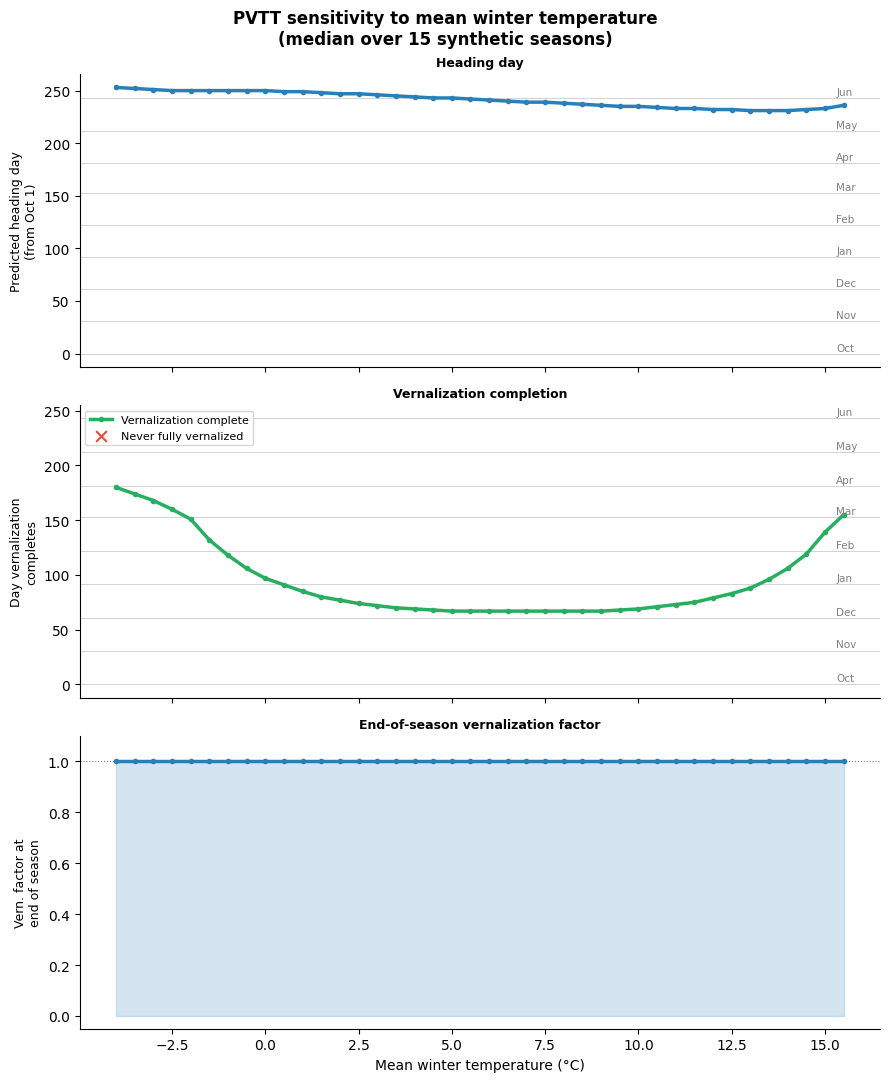

In [10]:
_MONTH_REFS = [
    (0, 'Oct'), (31, 'Nov'), (61, 'Dec'), (92, 'Jan'), (122, 'Feb'),
    (153, 'Mar'), (181, 'Apr'), (212, 'May'), (243, 'Jun'),
]

fig, axes = plt.subplots(3, 1, figsize=(9, 11), sharex=True)
fig.suptitle(f'PVTT sensitivity to mean winter temperature\n'
             f'(median over {N_SEEDS} synthetic seasons)',
             fontsize=12, fontweight='bold')

# — heading day ——————————————————————————————————————————————————————————
ax = axes[0]
valid = heading_days < 364
for doy, lab in _MONTH_REFS:
    ax.axhline(doy, color='lightgrey', lw=0.7, zorder=0)
    ax.text(15.3, doy + 1, lab, fontsize=7.5, va='bottom', color='grey')
ax.plot(WINTER_TEMPS[valid], heading_days[valid],
        color=C_PVTT, lw=2.5, marker='o', ms=3)
ax.set_ylabel('Predicted heading day\n(from Oct 1)', fontsize=9)
ax.set_title('Heading day', fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# — vernalization completion day ——————————————————————————————————————
ax = axes[1]
for doy, lab in _MONTH_REFS:
    ax.axhline(doy, color='lightgrey', lw=0.7, zorder=0)
    ax.text(15.3, doy + 1, lab, fontsize=7.5, va='bottom', color='grey')
valid_vd = ~np.isnan(vern_done_days)
ax.plot(WINTER_TEMPS[valid_vd], vern_done_days[valid_vd],
        color='#27ae60', lw=2.5, marker='o', ms=3, label='Vernalization complete')
ax.scatter(WINTER_TEMPS[~valid_vd], np.full((~valid_vd).sum(), 360),
           color='#e74c3c', marker='x', s=60, label='Never fully vernalized', zorder=5)
ax.set_ylabel('Day vernalization\ncompletes', fontsize=9)
ax.set_title('Vernalization completion', fontsize=9, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# — end-of-season vernalization factor ———————————————————————————————
ax = axes[2]
ax.axhline(1.0, color='grey', lw=0.8, ls=':')
ax.fill_between(WINTER_TEMPS, vern_eos, color=C_PVTT, alpha=0.2)
ax.plot(WINTER_TEMPS, vern_eos, color=C_PVTT, lw=2.5, marker='o', ms=3)
ax.set_xlabel('Mean winter temperature (°C)', fontsize=10)
ax.set_ylabel('Vern. factor at\nend of season', fontsize=9)
ax.set_title('End-of-season vernalization factor', fontsize=9, fontweight='bold')
ax.set_ylim(-0.05, 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Internal dynamics across winter temperature scenarios

Full PVTT internals for four contrasting winter temperatures, showing
the mechanism by which warm winters delay or suppress heading.

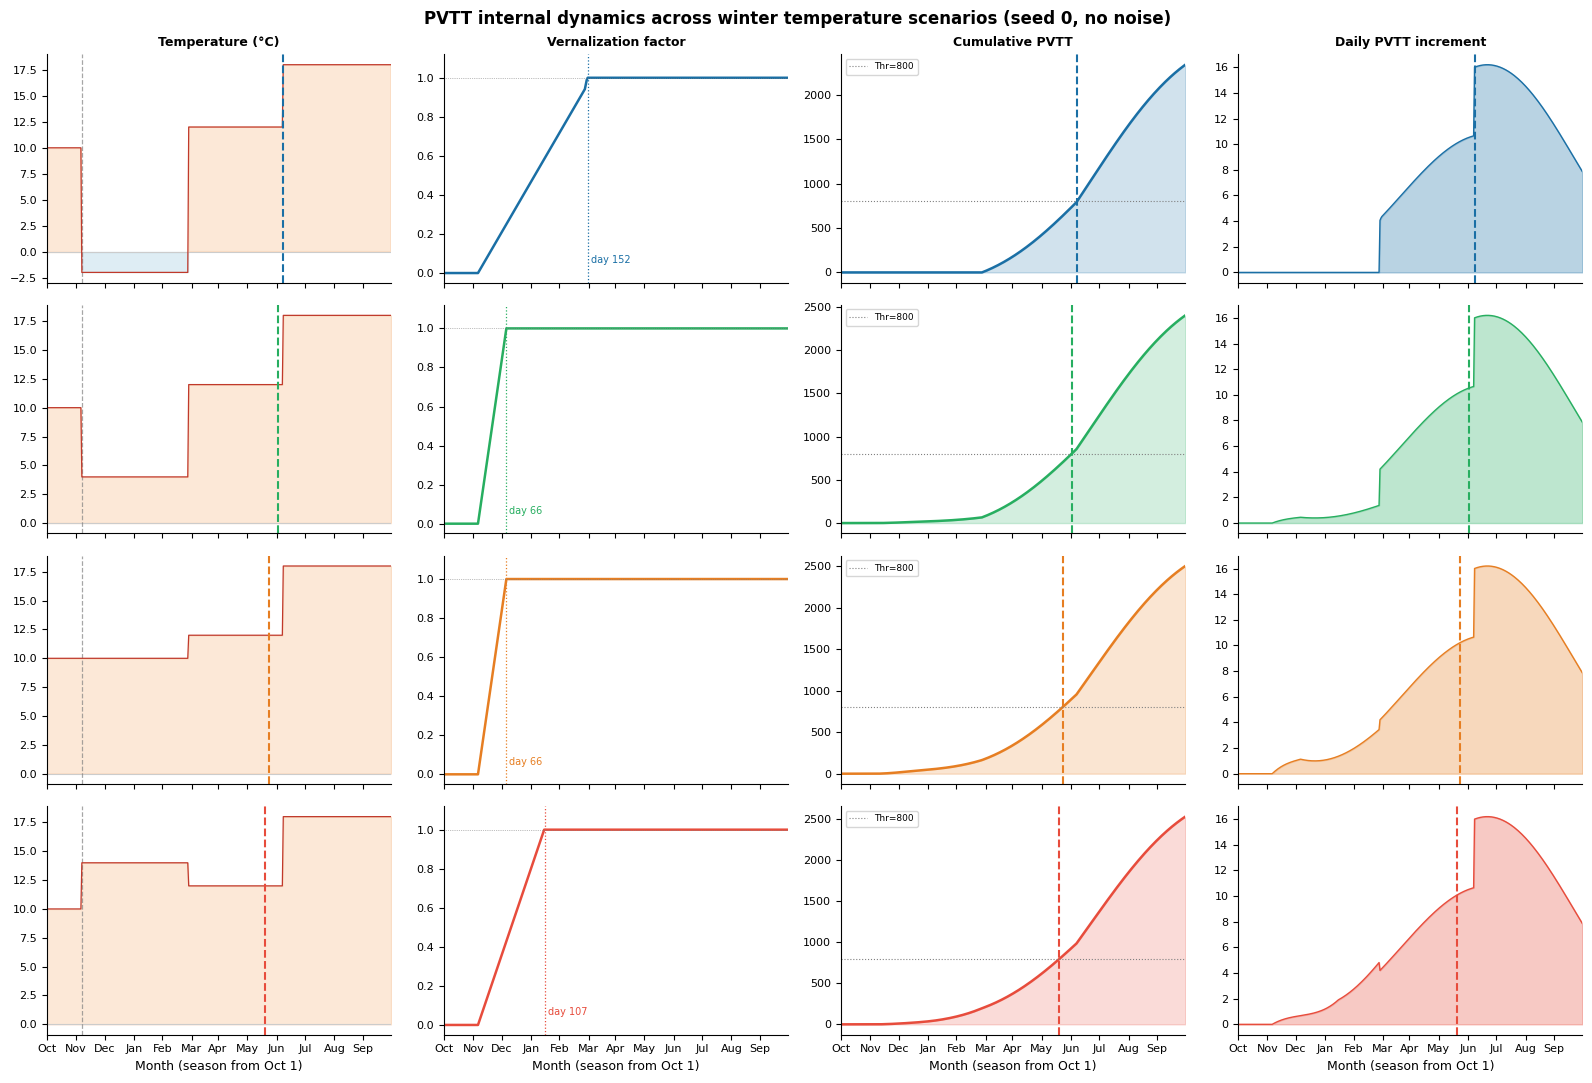

In [11]:
SCENARIOS = [
    ('Cold  (−2 °C)',   -2.0, '#1a6fa5'),
    ('Normal  (4 °C)',   4.0, '#27ae60'),
    ('Warm  (10 °C)',   10.0, '#e67e22'),
    ('Hot  (14 °C)',    14.0, '#e74c3c'),
]

N    = 365
days = np.arange(N)

fig, axes = plt.subplots(len(SCENARIOS), 4, figsize=(16, 11), sharex=True)
fig.suptitle('PVTT internal dynamics across winter temperature scenarios (seed 0, no noise)',
             fontsize=12, fontweight='bold')

for j, title in enumerate(['Temperature (°C)', 'Vernalization factor',
                             'Cumulative PVTT', 'Daily PVTT increment']):
    axes[0, j].set_title(title, fontsize=9, fontweight='bold')

for i, (label, mw, color) in enumerate(SCENARIOS):
    sample  = make_sample(mean_winter_temp=mw, seed=0, noise_std=0)
    ts      = sample[KEY_FEATURES]['temperature_2m_mean'].astype(float)
    ps      = sample[KEY_FEATURES]['daylight_duration'].astype(float) / 3600.0
    mask    = create_left_mask(N, TYPICAL_SOW_IX)

    vu      = func_vernalization_unit(ts) * mask
    vt      = func_vernalization_tres(vu.cumsum(), threshold=pvtt.threshold_vern)
    pf      = func_photoperiod_factor(ps, p_base=pvtt.p_base, p_sat=pvtt.p_saturation)
    gdu     = func_growing_degree_units_2(ts, t_base=pvtt.t_base,
                                          t_limit=pvtt.t_limit, t_upper=pvtt.t_upper)
    pvtt_d  = gdu * mask * vt * pf
    pvtt_cs = pvtt_d.cumsum()

    _, info = pvtt.predict(sample)
    pred_ix = info['ix']
    req_met = info['req_met']

    row_label = f'{label}\nday {pred_ix}' + ('' if req_met else ' [no heading]')

    # col 0 — temperature
    ax = axes[i, 0]
    ax.axhline(0, color=C_ZERO, lw=0.8)
    ax.axvline(TYPICAL_SOW_IX, color='grey', lw=0.9, ls='--', alpha=0.7)
    ax.fill_between(days, ts, 0, where=(ts >= 0), color=C_WARM)
    ax.fill_between(days, ts, 0, where=(ts <  0), color=C_COLD)
    ax.plot(days, ts, color=C_TLINE, lw=0.9)
    if req_met:
        ax.axvline(pred_ix, color=color, lw=1.5, ls='--')
    ax.set_ylabel(row_label, fontsize=7.5)
    _style_ax(ax, N, xlabel=(i == len(SCENARIOS) - 1))

    # col 1 — vernalization factor
    ax = axes[i, 1]
    ax.plot(days, vt, color=color, lw=1.8)
    ax.axhline(1.0, color='grey', lw=0.5, ls=':')
    done_ixs = np.where(vt >= 1.0)[0]
    if len(done_ixs):
        ax.axvline(done_ixs[0], color=color, lw=0.9, ls=':')
        ax.text(done_ixs[0] + 3, 0.05, f'day {done_ixs[0]}', fontsize=7, color=color)
    ax.set_ylim(-0.05, 1.12)
    _style_ax(ax, N, xlabel=(i == len(SCENARIOS) - 1))

    # col 2 — cumulative PVTT
    ax = axes[i, 2]
    ax.fill_between(days, pvtt_cs, color=color, alpha=0.2)
    ax.plot(days, pvtt_cs, color=color, lw=1.8)
    ax.axhline(pvtt.threshold_pvtt, color='grey', lw=0.8, ls=':',
               label=f'Thr={pvtt.threshold_pvtt:.0f}')
    if req_met:
        ax.axvline(pred_ix, color=color, lw=1.5, ls='--')
    ax.legend(fontsize=6.5, loc='upper left')
    _style_ax(ax, N, xlabel=(i == len(SCENARIOS) - 1))

    # col 3 — daily PVTT increment
    ax = axes[i, 3]
    ax.fill_between(days, pvtt_d, color=color, alpha=0.3)
    ax.plot(days, pvtt_d, color=color, lw=1.0)
    if req_met:
        ax.axvline(pred_ix, color=color, lw=1.5, ls='--')
    _style_ax(ax, N, xlabel=(i == len(SCENARIOS) - 1))

plt.tight_layout()
plt.show()

### 7b. Cumulative PVTT curves across the full winter temperature sweep

All synthetic winter temperature scenarios overlaid on one axis, coloured
by winter temperature.  Shows how the threshold is reached progressively
later (or not at all) as winters warm.

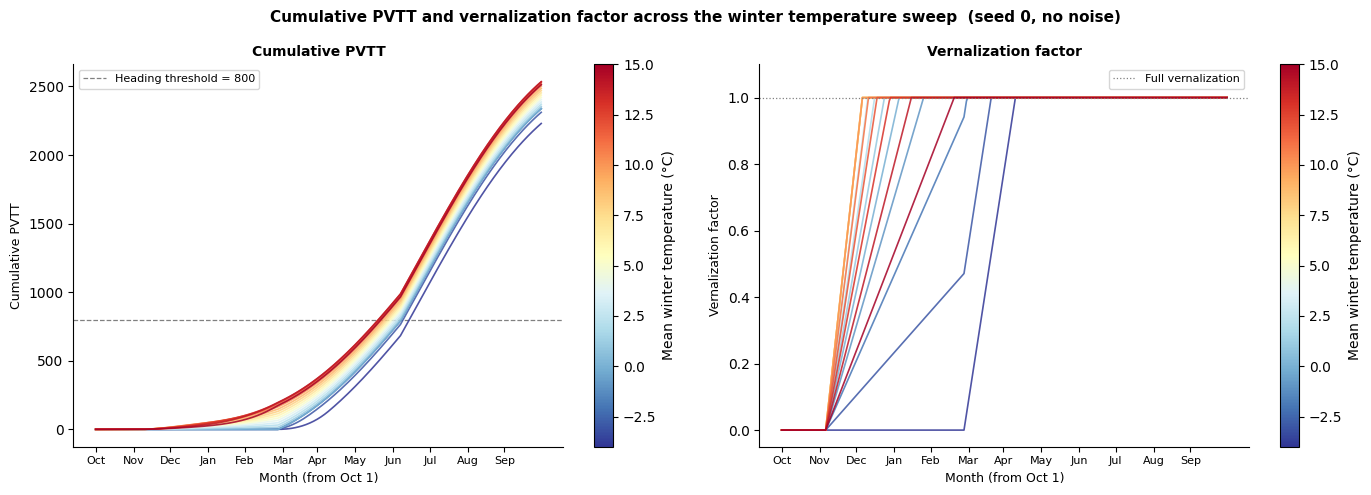

In [12]:
SWEEP_TEMPS = np.arange(-4, 16, 1.0)
cmap = plt.cm.RdYlBu_r
norm = plt.Normalize(SWEEP_TEMPS.min(), SWEEP_TEMPS.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cumulative PVTT and vernalization factor across the winter temperature sweep  (seed 0, no noise)',
             fontsize=11, fontweight='bold')

ax_pvtt = axes[0]
ax_vern = axes[1]

ax_pvtt.axhline(pvtt.threshold_pvtt, color='grey', lw=0.9, ls='--',
                label=f'Heading threshold = {pvtt.threshold_pvtt:.0f}')

for mw in SWEEP_TEMPS:
    sample  = make_sample(mean_winter_temp=mw, seed=0, noise_std=0)
    ts      = sample[KEY_FEATURES]['temperature_2m_mean'].astype(float)
    ps      = sample[KEY_FEATURES]['daylight_duration'].astype(float) / 3600.0
    mask    = create_left_mask(N, TYPICAL_SOW_IX)

    vu      = func_vernalization_unit(ts) * mask
    vt      = func_vernalization_tres(vu.cumsum(), threshold=pvtt.threshold_vern)
    pf      = func_photoperiod_factor(ps, p_base=pvtt.p_base, p_sat=pvtt.p_saturation)
    gdu     = func_growing_degree_units_2(ts, t_base=pvtt.t_base,
                                          t_limit=pvtt.t_limit, t_upper=pvtt.t_upper)
    pvtt_cs = (gdu * mask * vt * pf).cumsum()
    color   = cmap(norm(mw))

    ax_pvtt.plot(days, pvtt_cs, color=color, lw=1.2, alpha=0.85)
    ax_vern.plot(days, vt,      color=color, lw=1.2, alpha=0.85)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
for ax, ylabel, title in [
    (ax_pvtt, 'Cumulative PVTT', 'Cumulative PVTT'),
    (ax_vern, 'Vernalization factor', 'Vernalization factor'),
]:
    plt.colorbar(sm, ax=ax, label='Mean winter temperature (°C)')
    t, l = _month_ticks(N)
    ax.set_xticks(t)
    ax.set_xticklabels(l, fontsize=8)
    ax.set_xlabel('Month (from Oct 1)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax_pvtt.legend(fontsize=8)
ax_vern.axhline(1.0, color='grey', lw=0.9, ls=':', label='Full vernalization')
ax_vern.legend(fontsize=8)
ax_vern.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()